<a href="https://colab.research.google.com/github/Alaa-Boghdady/Chest-Xray-Pneumonia-Detection/blob/main/DL-approach/Chest_X_Ray_(Pneumonia_Deep_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing Libs ##

In [ ]:
# import system libs
import os # folds
import time
import shutil # folds
import pathlib # paths
import itertools #loops

# import Data Handling tools
import cv2 # img
import pandas as pd #df
import numpy as np #arrays
import matplotlib.pyplot as plt #plots
import seaborn as sns #cm
sns.set_style('darkgrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report # Evaluation

#import Deeplearning Libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam,Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation,Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras import regularizers #penalty

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print('modules loaded')

modules loaded




---



##Data Preprocessing ##

In [ ]:
# Read data and store it in DataFrame
import kagglehub
data = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [ ]:
train_data = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
filepaths = []
labels = []

folds = os.listdir(train_data)

for fold in folds:
  foldpath = os.path.join(train_data, fold) #P or N
  filelist = os.listdir(foldpath)
  for file in filelist:
    fpath = os.path.join(foldpath, file)
    filepaths.append(fpath)
    labels.append(fold)

Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')

df = pd.concat([Fseries,Lseries], axis = 1)

In [ ]:
df

,filepaths,labels
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
...,...,...
5211,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5212,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5213,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
5214,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL




---



In [ ]:
#split df into train, valid, test
#80% .. 12% .. 8%
#train df .. 4172  .. dummy .. 1044
train_df, dummy_df = train_test_split(df, train_size = 0.8, shuffle = True, random_state=123)

#valid & test df ..626 .. 418
valid_df, test_df = train_test_split(dummy_df, train_size = 0.6, shuffle=True, random_state=123)

In [ ]:
# Create Image Data Generator

#crobed image size
batch_size = 16
img_size  = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels) #(224, 224, 3)

# custom function for test data batch size
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range (1, ts_length+1) if ts_length % n == 0 and ts_length/n <=80 ]))
test_steps = ts_length // test_batch_size

def scalar(img):
  return img

tr_gen = ImageDataGenerator(preprocessing_function = scalar )
ts_gen = ImageDataGenerator(preprocessing_function = scalar )

#Generator
train_gen = tr_gen.flow_from_dataframe(
    train_df,
    x_col = 'filepaths',
    y_col = 'labels',
    target_size = img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen = ts_gen.flow_from_dataframe(
      valid_df,
    x_col = 'filepaths',
    y_col = 'labels',
    target_size = img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen = ts_gen.flow_from_dataframe(
      test_df,
    x_col = 'filepaths',
    y_col = 'labels',
    target_size = img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False, #
    batch_size=test_batch_size #
)


Found 4172 validated image filenames belonging to 2 classes.
Found 626 validated image filenames belonging to 2 classes.
Found 418 validated image filenames belonging to 2 classes.


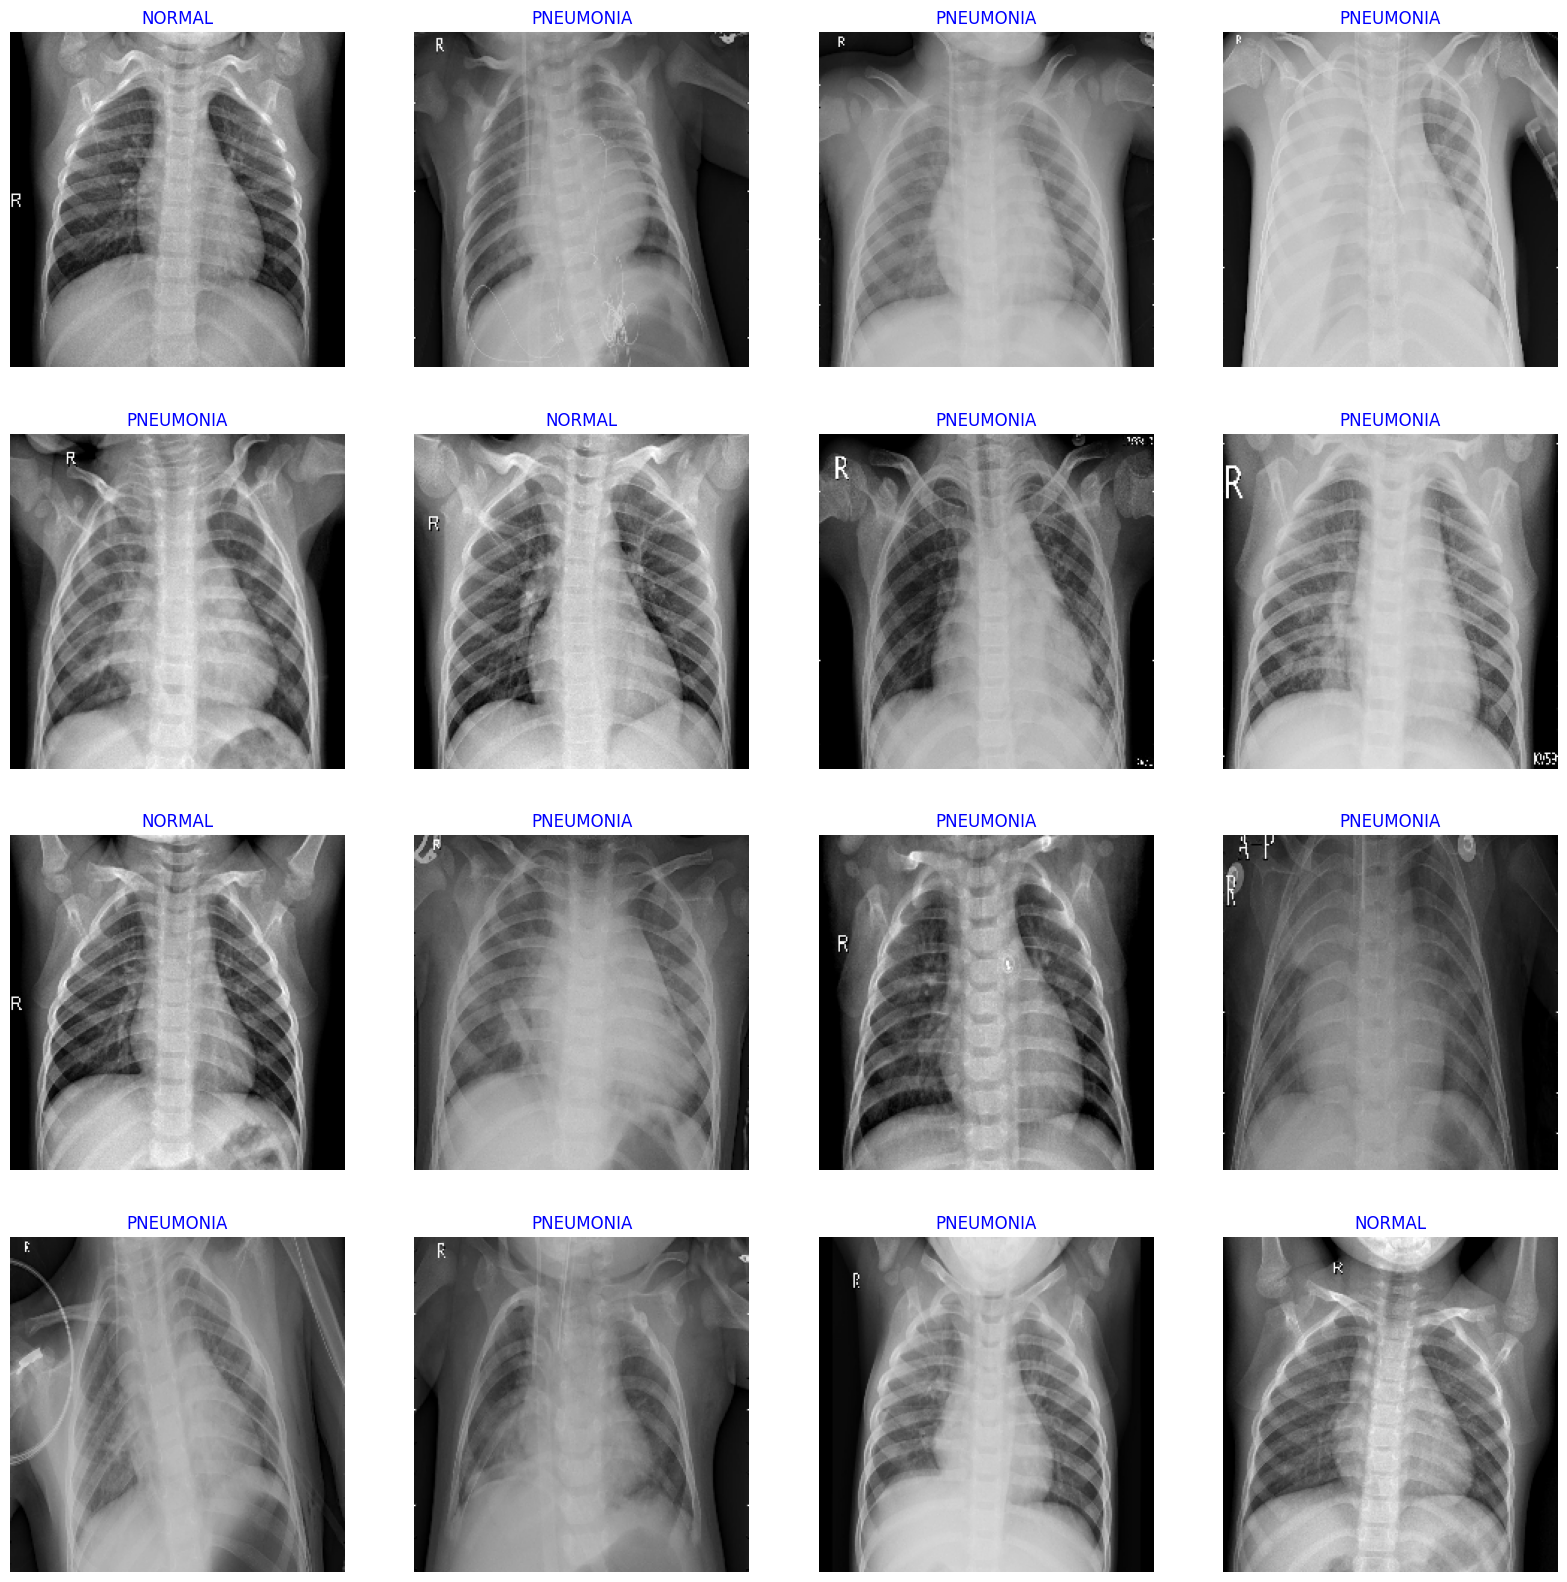

In [ ]:
# Show sample from train Data
g_dict = train_gen.class_indices
classes = list(g_dict.keys())
images, labels = next(train_gen)

plt.figure(figsize = (20,20))

for i in range(16):
  plt.subplot(4, 4, i+1)
  image = images[i]/255
  plt.imshow(image)
  index = np.argmax(labels[i])
  class_name = classes[index]
  plt.title(class_name, color = 'blue', fontsize = 12)
  plt.axis('off')

plt.show()



---



##Model Structure ##

In [ ]:
# Model Structure
img_size = (224,224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top = False , weights = "imagenet",
                                                               input_shape=img_shape,pooling = 'max' )

model = Sequential([
    base_model,
    BatchNormalization(axis = -1, momentum=0.99, epsilon = 0.001),
    Dense(256,
          kernel_regularizer=regularizers.l2(0.016),
          activity_regularizer = regularizers.l1(0.006),
          bias_regularizer= regularizers.l1(0.006), activation = 'relu'),
    Dropout(rate = 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

model.compile(
    Adamax(learning_rate = 0.001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy'])

model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,141 (16.72 MB)

 Trainable params: 4,338,558 (16.55 MB)

 Non-trainable params: 44,583 (174.16 KB)

In [ ]:
Early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# train model
batch_size = 8
epochs = 20

history = model.fit (x=train_gen, epochs = epochs , verbose = 1 , validation_data=valid_gen,
                     validation_steps=None, shuffle=False, callbacks=[Early_stop])


Epoch 1/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 1119s 4s/step - accuracy: 0.8480 - loss: 10.1247 - val_accuracy: 0.7508 - val_loss: 5.0694
Epoch 2/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 1070s 4s/step - accuracy: 0.8056 - loss: 4.6151 - val_accuracy: 0.7556 - val_loss: 3.3924
Epoch 3/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 1069s 4s/step - accuracy: 0.8072 - loss: 3.0784 - val_accuracy: 0.8578 - val_loss: 2.2388
Epoch 4/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 1067s 4s/step - accuracy: 0.8506 - loss: 2.0619 - val_accuracy: 0.9010 - val_loss: 1.5614
Epoch 5/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 1068s 4s/step - accuracy: 0.9022 - loss: 1.4033 - val_accuracy: 0.9585 - val_loss: 1.0295
Epoch 6/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 1064s 4s/step - accuracy: 0.9077 - loss: 0.9932 - val_accuracy: 0.9888 - val_loss: 0.9342
Epoch 7/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 1067s 4s/step - accuracy: 0.9266 - loss: 0.7547 - val_accuracy: 0.9633 - val_loss: 0.6920
Epoch 8/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 1066s 4s/step - accuracy: 0.9259 - loss: 0.6096 -



---



##Evaluate Model ##

In [ ]:
train_score = model.evaluate(train_gen, verbose = 1)
valid_score = model.evaluate(valid_gen, verbose = 1)
test_score = model.evaluate(test_gen, verbose = 1, steps = test_steps)

print("Train loss: " , train_score[0])
print("Train accuracy: ", train_score[1])
print("*"*20)
print("Valid loss: " , valid_score[0])
print("Valid accuracy: ", valid_score[1])
print("*"*20)
print("Test loss: " , test_score[0])
print("Test accuracy: ", test_score[1])

261/261 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9789 - loss: 0.2095
40/40 ━━━━━━━━━━━━━━━━━━━━ 37s 914ms/step - accuracy: 0.9804 - loss: 0.2139
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9971 - loss: 0.3392
Train loss:  0.20614267885684967
Train accuracy:  0.9798657894134521
********************
Valid loss:  0.2147308886051178
Valid accuracy:  0.9808306694030762
********************
Test loss:  0.33973610401153564
Test accuracy:  0.9952152967453003


In [ ]:
# prediction
preds = model.predict(test_gen, verbose = 1)
y_pred = np.argmax(preds, axis = 1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step


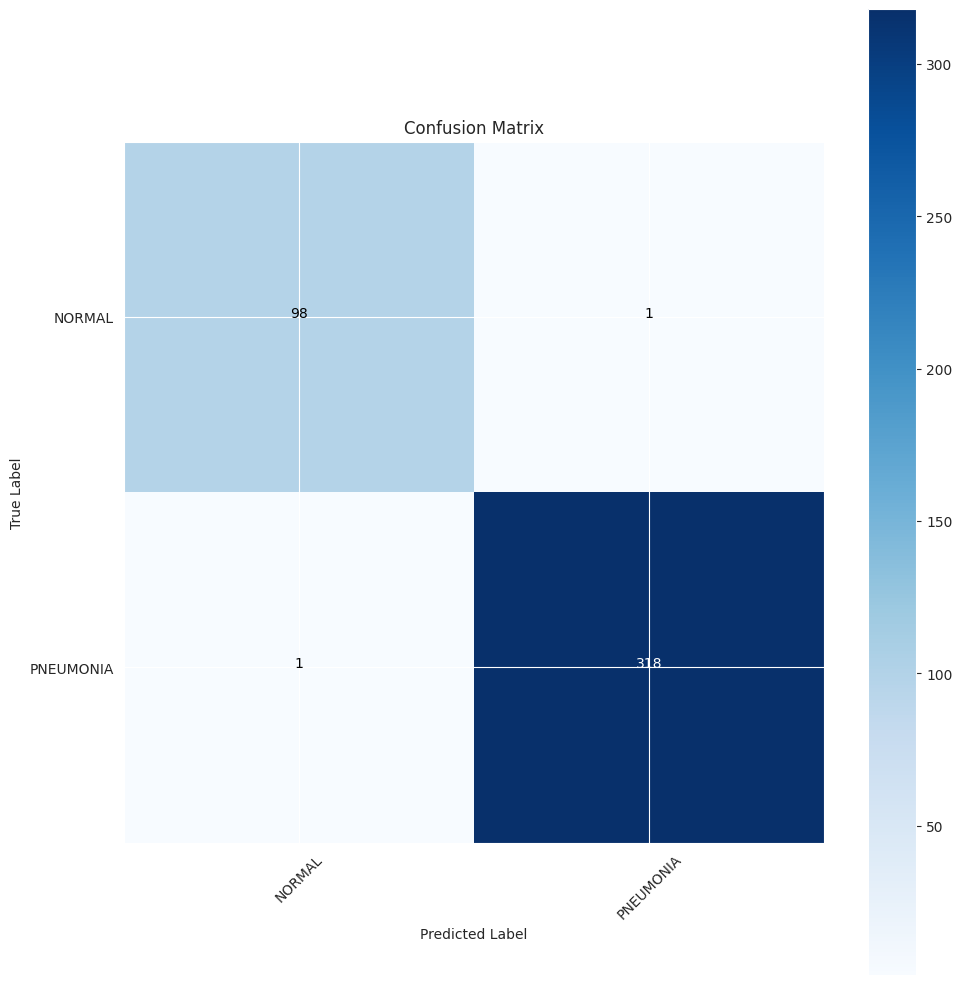

In [ ]:
# Confusion matrix
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize = (10,10))
plt.imshow(cm, interpolation = 'nearest', cmap = plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation = 45)
plt.yticks(tick_marks, classes)

thresh = cm.max()/2

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, cm[i,j], horizontalalignment='center', color = 'white' if cm[i,j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [ ]:
# Classification Report
print(classification_report (test_gen.classes, y_pred, target_names = classes))

              precision    recall  f1-score   support

      NORMAL       0.99      0.99      0.99        99
   PNEUMONIA       1.00      1.00      1.00       319

    accuracy                           1.00       418
   macro avg       0.99      0.99      0.99       418
weighted avg       1.00      1.00      1.00       418





---



##Evaluation on External Images ##

In [ ]:
treatment_plan = {
    "NORMAL": (
        "🟢 No Pneumonia Detected\n"
        "- Chest X-ray appears normal.\n"
        "- No treatment required.\n"
        "- Maintain healthy lifestyle."
    ),

    "PNEUMONIA": (
        "🔴 Pneumonia Detected\n"
        "- Consult a doctor immediately.\n"
        "- Antibiotics if bacterial pneumonia.\n"
        "- Antiviral treatment if viral.\n"
        "- Adequate rest and hydration.\n"
        "- Hospitalization may be required in severe cases."
    )
}


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving person100_bacteria_477.jpeg to person100_bacteria_477 (2).jpeg


In [ ]:
img_path = list(uploaded.keys())[0]
img = tf.keras.preprocessing.image.load_img(
    img_path, target_size = (224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)

pred = model.predict(img_array)
pred_index = np.argmax(pred)
confidence = np.max(pred)*100

class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[pred_index]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


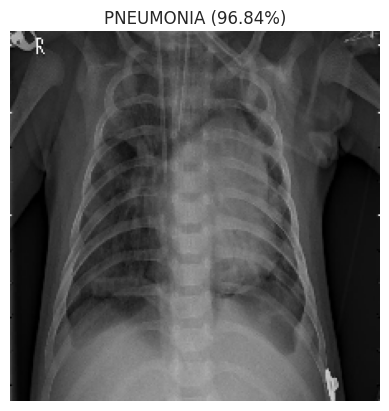

🖼️ Uploaded Image: person100_bacteria_477 (2).jpeg
✅ Diagnosis: PNEUMONIA
📊 Confidence: 96.84%

🩺 Suggested Treatment Plan:
🔴 Pneumonia Detected
- Consult a doctor immediately.
- Antibiotics if bacterial pneumonia.
- Antiviral treatment if viral.
- Adequate rest and hydration.
- Hospitalization may be required in severe cases.


In [ ]:
plt.imshow(img)
plt.axis('off')
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()

print("🖼️ Uploaded Image:", img_path)
print(f"✅ Diagnosis: {predicted_class}")
print(f"📊 Confidence: {confidence:.2f}%")

print("\n🩺 Suggested Treatment Plan:")
print(treatment_plan[predicted_class])



---



---

